# Depth Guided Next-Best-View Planning

**Author:** Andrew Chesang  
**Date:** February 2026  
**License:** Apache License 2.0

---

Copyright 2026 Andrew Chesang

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

    http://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.

---

This notebook aims to test the hypothesis that range images as a means of object 
representation are sufficient to propose candidate views for NBV.  Colored and corresponding depth images of similar resolution  from a virtual scene (Unity) are used for demonstration.

## Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"
import cv2
import pyvista as pv
pv.set_jupyter_backend('trame')

from utils import *

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## Load Images

Load color and depth images and create masks.

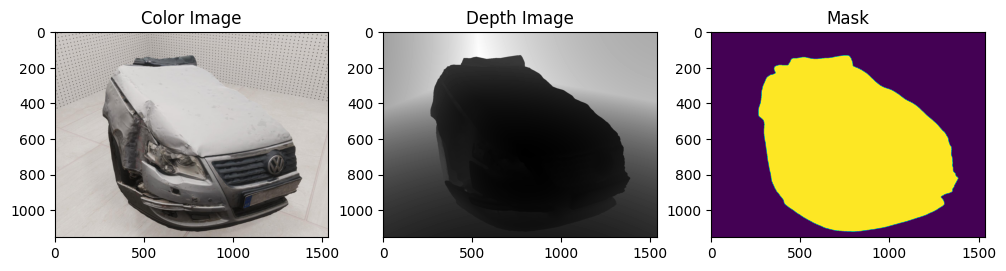

In [2]:
img_path = './DepthAnalysis/CrashedCar/4.jpg'
depth_path = './DepthAnalysis/CrashedCar/4.exr'

col_img = cv2.imread(img_path)
col_img = cv2.cvtColor(col_img, cv2.COLOR_BGR2RGB)

# Arbitrary scale factor to have depth value in metric units
# Set scale Factor to 1 if image is in metric units already
scale_factor = 10
dep_img = cv2.imread(depth_path, cv2.IMREAD_ANYCOLOR | cv2.IMREAD_ANYDEPTH) * scale_factor

fov = 60

mask = create_mask(col_img)
area = mask[mask > 0].size
occupancy = area/mask.size
rho = int(np.sqrt(area / np.pi)) 


plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.imshow(col_img)
plt.title('Color Image')
plt.subplot(132)
plt.imshow(dep_img, cmap='gray')
plt.title('Depth Image')
plt.subplot(133)
plt.imshow(mask)
plt.title('Mask')
plt.show()

## Feature Detection

Detect blobs in the depth image to identify surface irregularities and deformations.

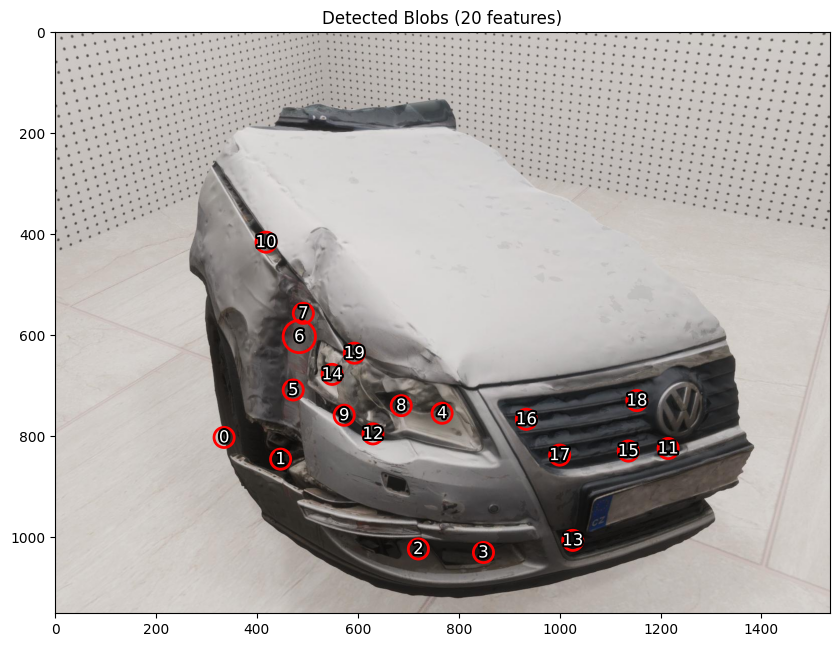

In [3]:
min_sigma = int(rho * 0.04)
max_sigma = int(rho * 0.2)

dep_blobs = compute_blobs(dep_img, min_sigma, max_sigma)
filtered_blobs = np.array(filter_blobs(dep_blobs, mask))

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(col_img)
add_patches_to_plot(ax, filtered_blobs, index=True)
plt.title(f'Detected Blobs ({len(filtered_blobs)} features)')
plt.show()

Found 11 clusters from 20 blobs


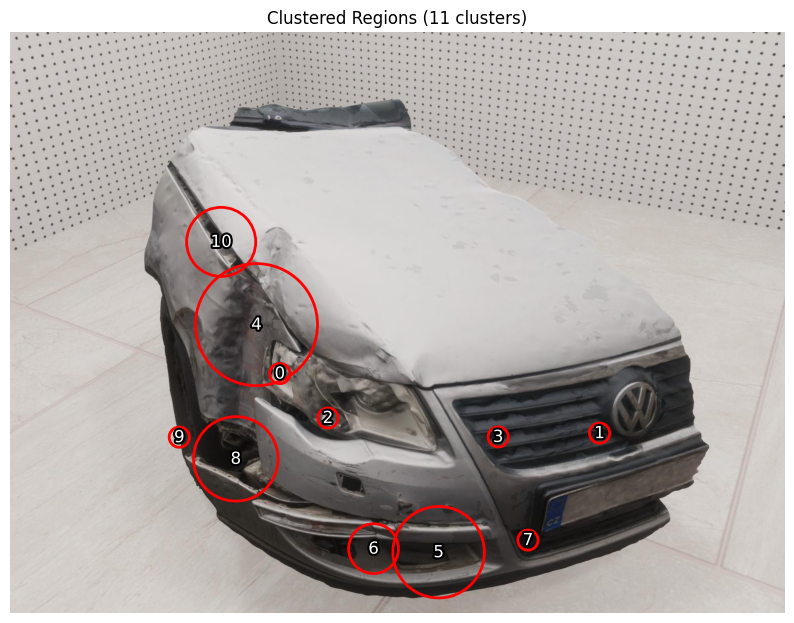

In [4]:
selected_bandwidth = rho * 0.2

clustered_blobs, labels, n_clusters = cluster_blobs(filtered_blobs, selected_bandwidth)

print(f'Found {n_clusters} clusters from {len(filtered_blobs)} blobs')

plt.figure(figsize=(10, 8))
plt.imshow(col_img)
plt.axis('off')
add_patches_to_plot(plt.gca(), clustered_blobs, index=True)
plt.title(f'Clustered Regions ({n_clusters} clusters)')
plt.show()

## Camera Pose Generation for Geometries of Interest

Computes primary and secondary camera poses for each detected blob, ensuring ground clearance and optimal viewing angles relative to the reference viewpoint.

In [12]:
img_width = col_img.shape[1]
img_height = col_img.shape[0]

focal_l = 6.0
fx, fy = (focal_l *  img_width/6.287, focal_l *  img_width/6.287)
cx, cy = ( img_width/2, img_height/2 )
intrinsics = o3d.camera.PinholeCameraIntrinsic(img_width, img_height, fx, fy, cx, cy)

In [13]:
# Hold all the Poses
local_poses = list()

roi_pos = list()

def generate_poses(plotter, blobs, image_col_m, image_dep_m, ):
    for blob in blobs:
        # Get Blob Centroid and Normal
        roi_col = isolate_image( image_col_m, blob )
        roi_dep = isolate_image( image_dep_m, blob )
        pcd, points, normals = create_point_cloud( [ roi_col, roi_dep ], intrinsics )
        centroid, normal = retrieve_normal(points, normals)
        
        roi_pos.append(centroid)
        
        # Create and add a sphere to represent a single point
        sphere = pv.Sphere(radius=.02, center=centroid)
        plotter.add_mesh(sphere, color='blue')
        
        # Calculate Primary Pose Position and Orientation
        blob_size_s = int(blob[2])/Rad
        wd = np.clip( blob_size_s * WD, min_wd, WD )
        priPose_loc = (normal * wd) + centroid
        
        # Avoid Floor Collision
        if priPose_loc[1] < y_min:
            print(f"Point: {priPose_loc} is below the floor at {y_min}" )
            priPose_loc[1] = y_min
            print(f"New Position: {priPose_loc}")
        priPose_rot = normalise_vector(centroid - priPose_loc)
        local_poses.append({ "pos" : priPose_loc, "rot" : priPose_rot })
        add_normal_to_plotter(plotter,priPose_loc, priPose_rot, "blue")

        # Get Secondary Pose
        v1 = priPose_loc - centroid
        v2 = viewpoint_centroid - centroid
        _, internal_angle = angle_difference(v1, v2)
        delta_angle = np.pi - internal_angle
        
        # Calculate Secondary Pose
        normal = np.cross(v1, v2)
        rot_axis = normal / np.linalg.norm(normal)
        theta = -np.pi/12 # Old form
        
        quat = R.from_rotvec(theta * rot_axis) # Create a quaternion for the rotation
        secPose_loc = quat.apply(v1) + centroid
        
        if secPose_loc[1] < y_min:
            print(f"Point: {secPose_loc} is below the floor at {y_min}" )
            secPose_loc[1] = y_min
            
            v3 = secPose_loc - centroid
            v4 = priPose_loc - centroid
            _deg, delta_angle2 = angle_difference(v3, v4)
            
            print(f"New Angle Delta: {_deg}")
            
            rot_axis2 = np.cross(v3, v4)
            rot_axis2 = rot_axis2/ np.linalg.norm(rot_axis2)
            quat2 = R.from_rotvec( (theta - delta_angle2)/2  * rot_axis2) # Create a quaternion for the rotation
            secPose_loc = quat2.apply(v3) + centroid
            secPose_loc[1] = y_min
            
        secPose_rot = normalise_vector( centroid - secPose_loc )
        local_poses.append({ "pos" : secPose_loc, "rot" : secPose_rot })
        add_normal_to_plotter(plotter,secPose_loc, secPose_rot, "yellow")
        
        

viewpoint_pcd,viewpoint_points, viewpoint_normals = create_point_cloud( [ mask_out( mask, col_img ), mask_out( mask, dep_img ) ], intrinsics )
viewpoint_centroid = np.mean(viewpoint_points, axis=0)

# Get Baselines for Blob Radius and Primary Pose Distance
eds = np.sqrt(np.sum((viewpoint_points - viewpoint_centroid)**2, axis=1))
ed_mean = np.mean(eds) 
ed_stdv = np.std(eds)
min_wd = ed_mean + (2 * ed_stdv)


WD = np.min(dep_img[mask > 0]) # Closest distance to the Camera(Reference Viewpoint) is the longest working distance
Rad = int(np.max(clustered_blobs[:,2]))
camera_offset = 0.1 # camera_offset is threshold distance that avoids clipping of the camera at lower vertical positions when it interferes with ground objects
y_min = np.ceil( np.min(viewpoint_points[:,1]) * 100)/100 + camera_offset

plotter = pv.Plotter()
generate_poses(plotter, clustered_blobs, col_img, dep_img)


vp_cloud = pv.PolyData(viewpoint_points)
plotter.add_points(vp_cloud, point_size=1)#, render_points_as_spheres=True)

# Create and add a sphere to represent a single point
centroid_sphere = pv.Sphere(radius=.05, center=viewpoint_centroid)

plotter.add_mesh(centroid_sphere, color='green')
plotter.view_xz()
plotter.show_grid()
plotter.show_axes()
plotter.show()


Widget(value='<iframe src="http://localhost:61076/index.html?ui=P_0x1a76e3ed840_1&reconnect=auto" class="pyvis…

## Look-At Vector Configuration

Constructs look-at transformation matrices by combining ROI centroids with their corresponding camera poses.

In [14]:
def create_lookat_vectors(roi_centroids, camera_poses):
    """Generate look-at vectors for camera pose configuration with coordinate transform."""
    lookat_configs = []
    coord_transform = np.array([1, -1, 1])
    
    for idx in range(len(roi_centroids)):
        pos1 = camera_poses[2*idx]['pos'] * coord_transform
        pos2 = camera_poses[2*idx + 1]['pos'] * coord_transform
        
        lookat_configs.append([
            roi_centroids[idx] * coord_transform,
            pos1,
            pos2
        ])
    
    return lookat_configs

lookat_vectors = create_lookat_vectors(roi_pos, local_poses)
print(f"Generated {len(lookat_vectors)} look-at configurations")


Generated 11 look-at configurations


In [15]:
lookat_vectors

[[array([-0.30799952, -0.13191898,  1.92462921]),
  array([-0.66433494, -0.05948492,  1.15704366]),
  array([-0.84851969, -0.10964649,  1.26983834])],
 [array([ 0.50838423, -0.27807197,  1.865168  ]),
  array([ 0.87614455, -0.51504594,  1.11853466]),
  array([ 1.05150689, -0.56048097,  1.25350749])],
 [array([-0.17083138, -0.23079463,  1.79464035]),
  array([-0.15034866,  0.05495963,  1.08812503]),
  array([-0.28547391, -0.08728955,  1.05470635])],
 [array([ 0.23551288, -0.26752702,  1.73890839]),
  array([ 0.5095157 , -0.50288896,  0.9616351 ]),
  array([ 0.65949829, -0.61778354,  1.08150189])],
 [array([-0.37813987, -0.00462335,  1.95418809]),
  array([-1.32106739, -0.09063059,  0.78560714]),
  array([-1.58265684,  0.02630736,  1.05403635])],
 [array([ 0.10278634, -0.58411591,  1.87761705]),
  array([-0.00827737, -0.30624126,  0.86343581]),
  array([ 0.04204748, -0.57447233,  0.82199835])],
 [array([-0.06388109, -0.58183168,  1.90495649]),
  array([-0.17998994, -0.12215543,  1.221910